# Projet de classification d'image de cellules afin de détecter le parasite de la Malaria
**Auteurs :** Capucine Schmidt, Clément Le Boulaire, Noé Vermaut

L'objectif de ce projet est de construire de A à Z un pipeline d'apprentissage automatique (Perceptron Multicouche) capable de différencier des globules rouges sains de globules parasités par la malaria.

## I. Imports

In [7]:
import os
import sys
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image

sys.path.append(os.path.abspath(".."))

%reload_ext autoreload
%autoreload 2

import Module.Pre_traitement as pre_traitement
import Module.MLP as mlp
import Module.Evaluation as eval
import Module.Application as app 
import Module.Affichages as aff

PROJET_RACINE = os.path.abspath("..")
UNINFECTED_PATH = os.path.join(PROJET_RACINE, "Data", "Uninfected")
PARASITIZED_PATH = os.path.join(PROJET_RACINE, "Data", "Parasitized")

## II. Chargement et exploration des données
Nous chargeons les images, les redimensionnons (32x32), et extrayons un vecteur hybride contenant à la fois les pixels et 8 descripteurs.

Extraction des caractéristiques pour 1000 images par classe...
Dataset chargé : 2000 images, 1033 variables par image.



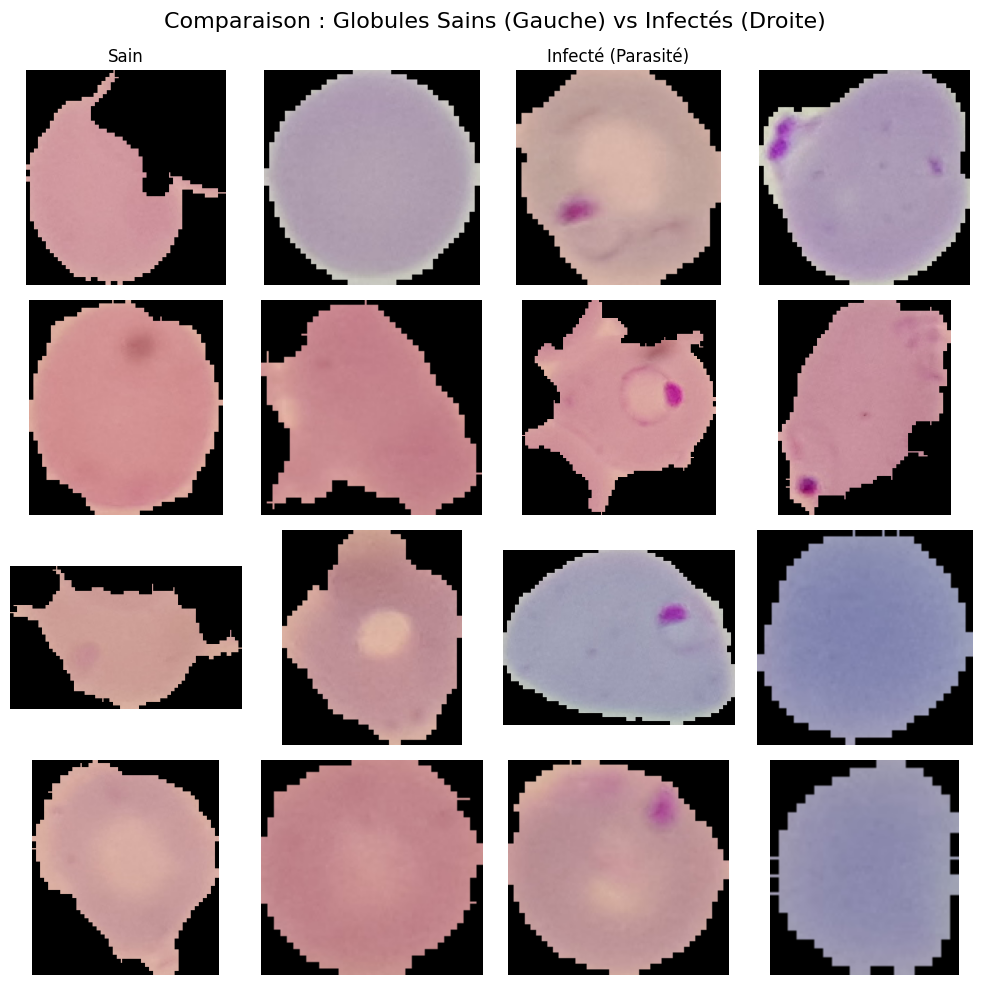

Analyse de la distribution des deux classes dans l'espace latent (PCA) :


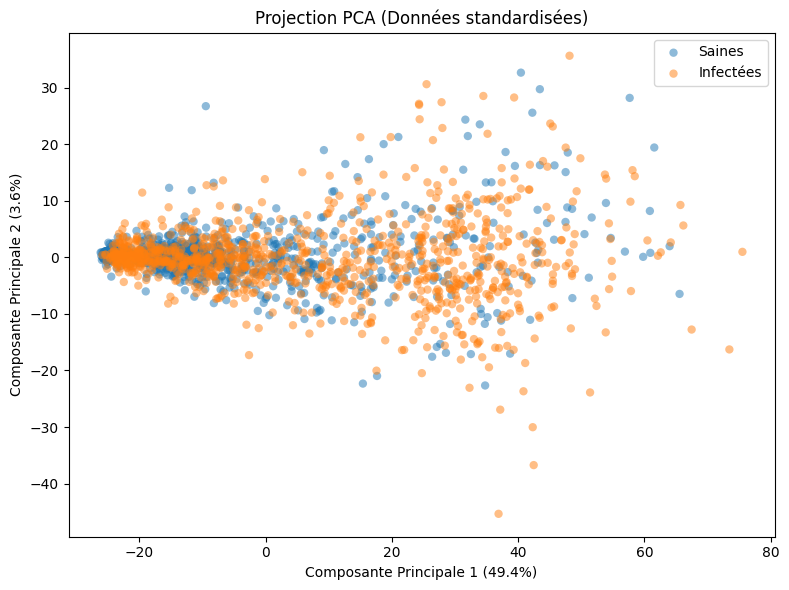

In [3]:
print(f"Extraction des caractéristiques pour {mlp.MAX_IMAGES} images par classe...")

data, target = mlp.load_images(
    uninfected_dir=UNINFECTED_PATH,
    parasitized_dir=PARASITIZED_PATH,
    image_size=mlp.TAILLE_IMAGE,
    max_per_class=mlp.MAX_IMAGES
)

print(f"Dataset chargé : {data.shape[0]} images, {data.shape[1]} variables par image.\n")

# 1. Affichage de quelques échantillons bruts
aff.plot_image_grid(UNINFECTED_PATH, PARASITIZED_PATH)

# 2. Visualisation de la séparabilité des données (PCA)
print("Analyse de la distribution des deux classes dans l'espace latent (PCA) :")
aff.plot_advanced_eda(data, target)

## III. Sélection du Modèle (Recherche d'Hyperparamètres)
Pour optimiser au mieux notre réseau, nous lançons une recherche aléatoire (Random Search) couplée à un mécanisme d'élagage (Pruning) pour trouver rapidement la meilleure architecture.

In [ ]:
print("Lancement de la recherche d'hyperparamètres...")
best_config, all_results = mlp.random_search_hyperparameters(
    data=data,
    target=target,
    train_func=mlp.mlp_fit_minibatch,
    predict_func=mlp.predict_relu,
    hidden_layer_configs=[[32, 16], [64, 32], [128, 64]],
    batch_sizes=[16, 32, 64],
    learning_rate_range=(0.001, 0.05),
    n_trials=10,
    random_state=42
)

# Sauvegarde de la meilleure configuration d'hyperparamètres
mlp.save_best_hyperparameters("best_hyperparams.npy", best_config)

Lancement de la recherche d'hyperparamètres...

TRIAL 1/10
hidden_layers : [32, 16]
batch_size    : 64
learning_rate : 0.005567
--- Fold 1/3 ---
Accuracy fold 1 : 0.7091 | Loss : 0.5027
--- Fold 2/3 ---
Accuracy fold 2 : 0.7226 | Loss : 0.4513
--- Fold 3/3 ---
Accuracy fold 3 : 0.7447 | Loss : 0.4757

Accuracy moyenne : 0.7255
→ accuracy = 0.7255

TRIAL 2/10
hidden_layers : [64, 32]
batch_size    : 64
learning_rate : 0.015304
--- Fold 1/3 ---
Accuracy fold 1 : 0.7661 | Loss : 0.1994
--- Fold 2/3 ---
Accuracy fold 2 : 0.7676 | Loss : 0.1965
--- Fold 3/3 ---
Accuracy fold 3 : 0.7883 | Loss : 0.2026

Accuracy moyenne : 0.7740
→ accuracy = 0.7740

TRIAL 3/10
hidden_layers : [32, 16]
batch_size    : 16
learning_rate : 0.045452
--- Fold 1/3 ---
Accuracy fold 1 : 0.8186 | Loss : 0.0720
--- Fold 2/3 ---
Accuracy fold 2 : 0.7796 | Loss : 0.0597
--- Fold 3/3 ---
Accuracy fold 3 : 0.7823 | Loss : 0.1245

Accuracy moyenne : 0.7935
→ accuracy = 0.7935

TRIAL 4/10
hidden_layers : [128, 64]
batch_siz

## IV. Entrainement (Cross-Validation K-Fold)
En utilisant les meilleurs hyperparamètres trouvés, nous entrainons et testons la robustesse de notre modèle via une Validation Croisée à 5 plis. À l'intérieur de la boucle de validation, nous appliquons une ACP ciblée uniquement sur les pixels pour réduire le bruit tout en conservant nos descripteurs additionnels.

Exécution de la Validation Croisée (5 Folds)...
--- Fold 1/5 ---
    -> Early Stopping à l'époque 148 (Loss opt: 0.0112)
Accuracy fold 1 : 0.8025 | Loss : 0.0204
--- Fold 2/5 ---
Accuracy fold 2 : 0.7750 | Loss : 0.0273
--- Fold 3/5 ---
Accuracy fold 3 : 0.7975 | Loss : 0.0073
--- Fold 4/5 ---
Accuracy fold 4 : 0.8050 | Loss : 0.0135
--- Fold 5/5 ---
    -> Early Stopping à l'époque 133 (Loss opt: 0.0109)
Accuracy fold 5 : 0.7825 | Loss : 0.0157

Accuracy moyenne : 0.7925


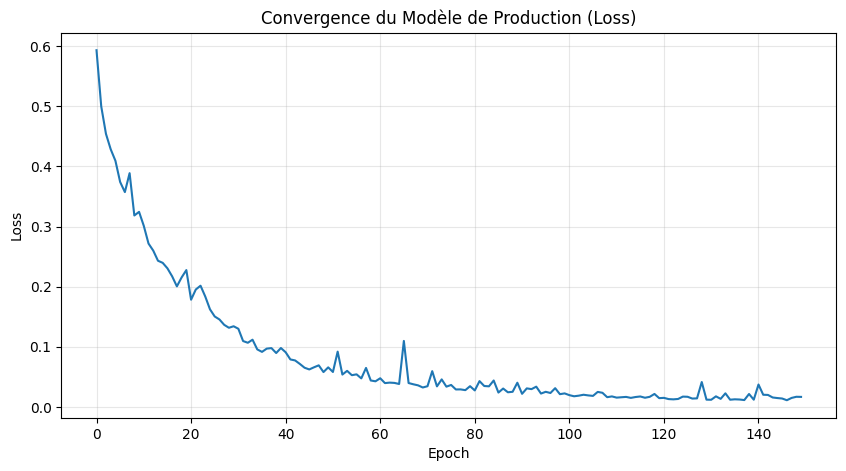

In [11]:
print(f"Exécution de la Validation Croisée (5 Folds)...")

cv_results= mlp.cross_validation(
    data=data, 
    target=target, 
    train_func=mlp.mlp_fit_minibatch, 
    predict_func=mlp.predict_relu, 
    n_folds=5, 
    learning_rate=best_config["learning_rate"], 
    hidden_layer_sizes=best_config["hidden_layers"], 
    batch_size=best_config["batch_size"],
    random_state=42
)

# Calcul de la moyenne des pertes 
losses = mlp.mean_losses(cv_results["losses"])

# Visualisation de la convergence (Loss)
aff.plot_losses(losses, title="Convergence du Modèle de Production (Loss)")


## V. Analyse des Métriques ##
Dans un contexte de diagnostic médical, notre métrique de priorité est le Rappel (Recall) : il est vital de minimiser les Faux Négatifs (patients infectés renvoyés chez eux).

=== RAPPORT CLINIQUE FINAL ===
Exactitude (Accuracy) : 0.7925
Précision             : 0.8095
Rappel (Recall)       : 0.7650
Score F1              : 0.7866
Affichage de la Matrice de confusion normalisée...


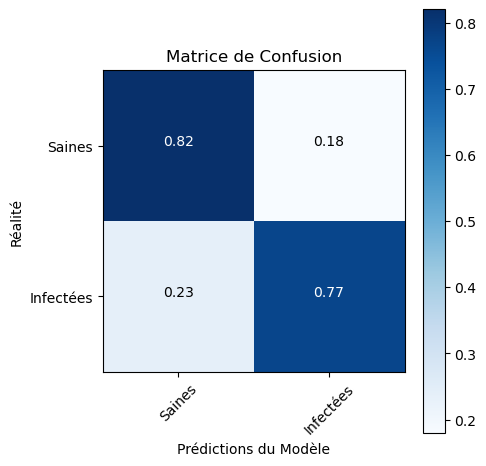

In [5]:
# Extraction de la matrice globale depuis le dictionnaire retourné par la CV
mc_globale = cv_results["confusion_matrix"]

acc = eval.exactitude(mc_globale)
prec = eval.precision(mc_globale)
rap = eval.rappel(mc_globale)
f1 = eval.score_f1(prec, rap)

print("=== RAPPORT CLINIQUE FINAL ===")
print(f"Exactitude (Accuracy) : {acc:.4f}")
print(f"Précision             : {prec:.4f}")
print(f"Rappel (Recall)       : {rap:.4f}")
print(f"Score F1              : {f1:.4f}")

# Formatage pour le graphique
cm_array = np.array([[mc_globale['VN'], mc_globale['FP']], 
                     [mc_globale['FN'], mc_globale['VP']]])

plt.figure(figsize=(5, 5))
eval.plot_confusion_matrix(cm_array, classes=['Saines', 'Infectées'], normalize=True)
plt.show()

## V. Entraînement et Sauvegarde
Le comportement de notre réseau étant validé, nous l'entraînons une dernière fois sur 100 % des données disponibles (les 2000 images ici) pour capturer un maximum d'information avant de l'exporter.

Préparation du modèle de production...


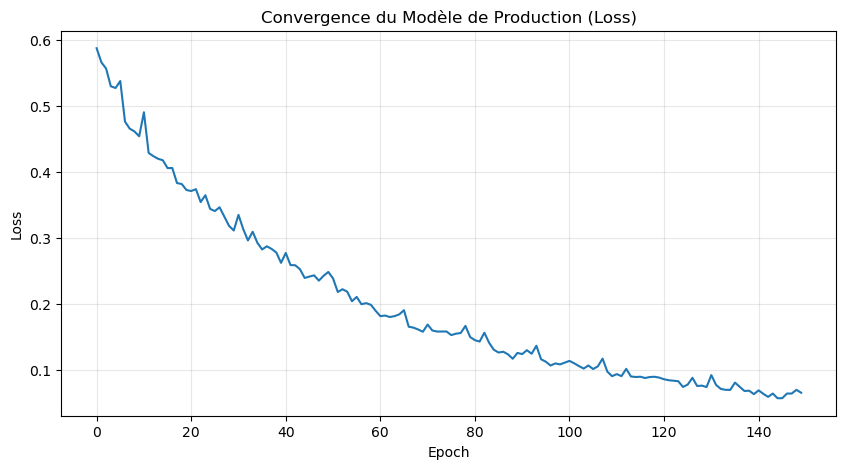

Modèle 'modele_malaria.npz' sauvegardé avec succès et prêt au déploiement.


In [6]:
print("Préparation du modèle de production...")

# 1. Normalisation globale stricte
mean_final = np.mean(data, axis=0)
std_final = np.std(data, axis=0)
std_final = np.where(std_final < 1e-8, 1e-8, std_final)
data_scaled = np.clip((data - mean_final) / std_final, -5, 5)

# 2. Séparation Pixels / Experts
n_pixels = mlp.TAILLE_IMAGE[0] * mlp.TAILLE_IMAGE[1]
data_pixels = data_scaled[:, :n_pixels]
data_experts = data_scaled[:, n_pixels:]

# 3. Réduction de dimension (PCA) réservée aux pixels
pca_final = mlp.PCA(n_components=mlp.COMPOSANTES_PCA, random_state=42)
data_pixels_pca = pca_final.fit_transform(data_pixels)

# 4. Fusion du vecteur d'entrée final
data_production = np.concatenate([data_pixels_pca, data_experts], axis=1)

# 5. Entraînement Final
w_final, b_final, losses = mlp.mlp_fit_minibatch(
    data_production, target, 
    n_epochs=mlp.EPOCHS, 
    hidden_layer_sizes=best_config["hidden_layers"],
    learning_rate=best_config["learning_rate"], 
    batch_size=best_config["batch_size"], 
    random_state=42, 
    dropout_rate=mlp.TAUX_DROPOUT, 
    patience=mlp.PATIENCE, 
    lambda_reg=mlp.LAMBDA_L2
)

# Visualisation de la convergence (Loss)
aff.plot_losses(losses, title="Convergence du Modèle de Production (Loss)")

# 6. Sauvegarde du modèle final
mlp.save_model("modele_malaria.npz", w_final, b_final, mean_final, std_final, pca_final.components_, pca_final.mean_)
print("Modèle 'modele_malaria.npz' sauvegardé avec succès et prêt au déploiement.")